Problemas de Estadística Descriptiva
#Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?
En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:

Calcular la longitud del título (en caracteres).
Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
Identificar los títulos más largos y más cortos.
Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [ ]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics as stats
from scipy.stats import skew, kurtosis, mode

# Cargar dataset de IMDb
import kagglehub

url = "/content/imdb_top_1000.csv"
df = pd.read_csv(url)
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


In [ ]:
df.head()
df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
 16  title_length   1000 non-null   int64  
dtypes: float64(2), int64(2), object(13)
memory usage: 132

Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título

In [ ]:
df["title_length"] = df["Series_Title"].str.len()
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,title_length
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",24
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",13
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444",15
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000",22
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000",12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN,22
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN,5
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000",21
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN,8


Calcula media, mediana y moda de la columna 'title_length'

In [ ]:
df.title_length.mean() # calculamos la media
print(df.title_length.mean())
df.title_length.median() # calculamos la mediana
print(df.title_length.median())
df.title_length.mode() # calculamos la moda
print(df.title_length.mode())

# tambien lo podemos hacer de la siguiente manera (stats.multimode para ver si hay mas de una moda)

mean_length = df['title_length'].mean()
median_length = df['title_length'].median()
mode_length = stats.multimode(df['title_length'])

print(f"Media: {mean_length}, Mediana: {median_length}, Moda: {mode_length}")


15.452
14.0
0    12
Name: title_length, dtype: int64
Media: 15.452, Mediana: 14.0, Moda: [12]


Calcula el rango, la varianza y la desviación estándar de 'title_length'

In [ ]:
range_length = df['title_length'].max() - df['title_length'].min()
variance_length = df['title_length'].var()
std_length = df['title_length'].std()

print(f"Rango: {range_length}, Varianza: {variance_length}, Desviación Estándar: {std_length}")

Rango: 66, Varianza: 68.271967967968, Desviación Estándar: 8.262685275863289


Calcula asimetría y curtosis de la columna 'title_length'


In [ ]:
asimetria = df['title_length'].skew()
curtosis = df['title_length'].kurtosis()

print(f"asimetría: {asimetria}, curtosis: {curtosis}")

asimetría: 1.4504489484648102, curtosis: 3.6664033112738195


Imprime el título más corto y el título más largo según su longitud


In [ ]:
short_title = df['title_length'].idxmin()
long_title = df['title_length'].idxmax()



print(f"el titulo de la corta es {df.iloc[short_title]["Series_Title"]} y el titulo de la larga es {df.iloc[long_title]["Series_Title"]}")




el titulo de la corta es Up y el titulo de la larga es Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb


Grafica tus resultados

/tmp/ipython-input-2770845720.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


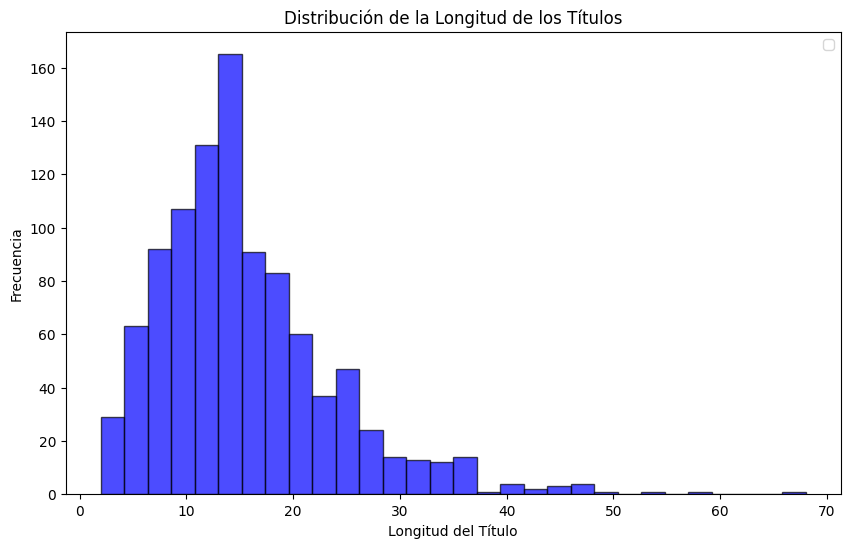

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['title_length'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribución de la Longitud de los Títulos')
plt.xlabel('Longitud del Título')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


#Ejercicio 2 – Cálculo manual de desviación estándar

Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]


In [ ]:
data = [10, 13, 14, 18, 22]

Calcula la media de los 5 valores


In [ ]:
media_data = sum(data) / len(data)
print(media_data)

15.4


Calcula las diferencias al cuadrado con respecto a la media


In [ ]:
suma_diferencias = sum((x - media_data)**2 for x in data)
print(suma_diferencias)

87.2


Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación

In [ ]:
varianza_data = suma_diferencias / len(data)
desviacion = varianza_data ** 0.5
print(desviacion)

# otra opción para calcular raiz cuadrad con math
math.sqrt(varianza_data)

4.17612260356422


4.17612260356422